  Using cached tzdata-2026.3-py2.py3-none-any.whl.metadata (1.4 kB)
  Using cached absl_py-2.5.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached flatbuffers-25.12.19-py2.py3-none-any.whl.metadata (1.0 kB)
  Using cached gast-0.7.0-py3-none-any.whl.metadata (1.5 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached libclang-18.1.1-py2.py3-none-win_amd64.whl.metadata (5.3 kB)
  Using cached opt_einsum-3.4.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached protobuf-7.36.1-cp310-abi3-win_amd64.whl.metadata (595 bytes)
  Using cached requests-2.34.2-py3-none-any.whl.metadata (4.8 kB)
  Using cached setuptools-84.0.0-py3-none-any.whl.metadata (6.6 kB)
  Using cached termcolor-3.3.0-py3-none-any.whl.metadata (6.5 kB)
  Using cached keras-3.15.1-py3-none-any.whl.metadata (6.4 kB)
  Using cached joblib-1.6.0-py3-none-any.whl.metadata (6.5 kB)
  Using cached narwhals-2.26.0-py3-none-any


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 417 (1.63 KB)

 Trainable params: 417 (1.63 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5424 - loss: 1.6471 - val_accuracy: 0.6354 - val_loss: 0.6579
Epoch 2/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5979 - loss: 0.6898 - val_accuracy: 0.5479 - val_loss: 0.7916
Epoch 3/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6014 - loss: 0.6623 - val_accuracy: 0.6458 - val_loss: 0.6273
Epoch 4/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6273 - loss: 0.6526 - val_accuracy: 0.6438 - val_loss: 0.6288
Epoch 5/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6130 - loss: 0.6501 - val_accuracy: 0.6313 - val_loss: 0.6376
Epoch 6/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6256 - loss: 0.6441 - val_accuracy: 0.6646 - val_loss: 0.6327
Epoch 7/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6202 - loss: 0.6444 - val_accuracy: 0.6604 - val_loss: 0.6330
Epoch 8/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6238 - loss: 0.6436 - val_accuracy: 0.6417 - val_loss:

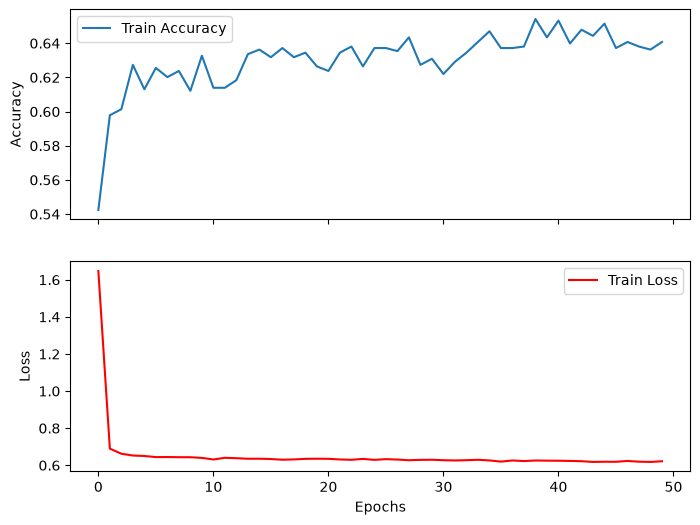

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
TP: 260 | FP: 138 | TN: 55 | FN: 27


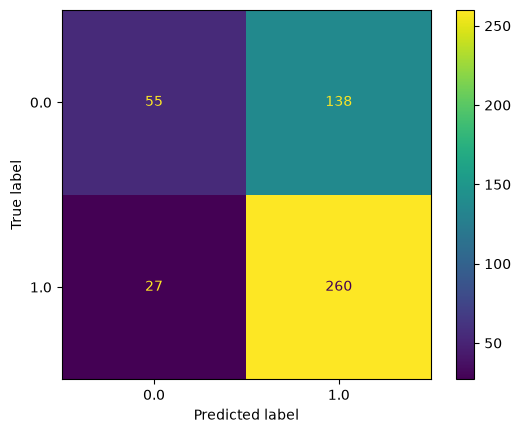

In [1]:
import sys
!{sys.executable} -m pip install numpy pandas tensorflow scikit-learn matplotlib
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Load dataset
training_data = pd.read_csv('./wine.csv')

# Separate target and encode strings to integers (good: 1, bad: 0)
training_y = training_data.pop('quality')
training_y.replace("good", 1, inplace=True)
training_y.replace("bad", 0, inplace=True)

training_x = training_data

# Convert Pandas DataFrames to NumPy float32 arrays for Keras
arr_train_x = training_x.to_numpy().astype("float32")
arr_train_y = training_y.to_numpy().astype("float32")

# Hold-out evaluation split (70% train, 30% test)
X_train, X_test, Y_train, Y_test = train_test_split(
    arr_train_x, arr_train_y, test_size=0.3, random_state=2, shuffle=True
)

model = keras.Sequential([
    layers.InputLayer(shape=(11,)),
    layers.Dense(32, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

model.summary()

model.compile(
    loss='binary_crossentropy',
    optimizer='sgd',
    metrics=['accuracy']
)

# Train on the training set
model_training_history = model.fit(
    X_train, 
    Y_train, 
    epochs=50, 
    batch_size=32, 
    validation_data=(X_test, Y_test)
)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 6), sharex=True)

acc = model_training_history.history['accuracy']
loss = model_training_history.history['loss']

ax1.plot(acc, label='Train Accuracy')
ax1.set_ylabel('Accuracy')
ax1.legend()

ax2.plot(loss, label='Train Loss', color='red')
ax2.set_ylabel('Loss')
ax2.set_xlabel('Epochs')
ax2.legend()

plt.show()

# Predict probabilities on holdout test set
y_pred_probs = model.predict(X_test)
y_pred = np.round(y_pred_probs)  # Thresholding >= 0.5 -> 1, < 0.5 -> 0

# Confusion Matrix components
tn, fp, fn, tp = confusion_matrix(Y_test, y_pred).ravel()

print(f"TP: {tp} | FP: {fp} | TN: {tn} | FN: {fn}")

# Display matrix visually
ConfusionMatrixDisplay.from_predictions(Y_test, y_pred)
plt.show()